<a href="https://colab.research.google.com/github/hanifanwibawa/datanaly/blob/Forecast_BBCA/Forecast_BBCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance pmdarima prophet keras-tuner

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler

# algoritma ML
from xgboost import XGBRegressor
from pmdarima import auto_arima
from prophet import Prophet

# DeepLearning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Tuning
import keras_tuner as kt

In [ ]:
# check gpu for tensorflow
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [ ]:
# yfinance

ticker = 'BBCA.JK'
period = 'max'
interval = '1d'

df = yf.download(ticker, period=period, interval=interval)

/tmp/ipython-input-3586162109.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period=period, interval=interval)
[*********************100%***********************]  1 of 1 completed


In [ ]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,BBCA.JK,BBCA.JK,BBCA.JK,BBCA.JK,BBCA.JK
Date,,,,,
2004-06-08,99.041351,100.436300,97.646403,97.646403,499150000
2004-06-09,100.436272,101.831220,97.646375,99.041323,294290000
2004-06-10,100.436272,100.436272,99.041323,100.436272,165590000
2004-06-11,100.436272,100.436272,99.041323,99.041323,135830000
2004-06-14,99.041351,100.436300,97.646403,100.436300,158540000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5306 entries, 2004-06-08 to 2025-12-04
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, BBCA.JK)   5306 non-null   float64
 1   (High, BBCA.JK)    5306 non-null   float64
 2   (Low, BBCA.JK)     5306 non-null   float64
 3   (Open, BBCA.JK)    5306 non-null   float64
 4   (Volume, BBCA.JK)  5306 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 248.7 KB


In [ ]:
df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]

df = df[['Open', 'Close', 'High', 'Low', 'Volume']]

In [ ]:
df.head()

,Open,Close,High,Low,Volume
Date,,,,,
2004-06-08,97.646403,99.041351,100.436300,97.646403,499150000
2004-06-09,99.041323,100.436272,101.831220,97.646375,294290000
2004-06-10,100.436272,100.436272,100.436272,99.041323,165590000
2004-06-11,99.041323,100.436272,100.436272,99.041323,135830000
2004-06-14,100.436300,99.041351,100.436300,97.646403,158540000


In [ ]:
df.tail()

,Open,Close,High,Low,Volume
Date,,,,,
2025-11-28,8270.327889,8220.656250,8295.163708,8220.656250,67559300
2025-12-01,8394.507580,8344.835938,8394.507580,8295.164295,76359200
2025-12-02,8295.164179,8320.000000,8369.671642,8295.164179,97044000
2025-12-03,8350.000000,8300.000000,8400.000000,8300.000000,103550900
2025-12-04,8325.000000,8250.000000,8350.000000,8225.000000,31458300


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5306 entries, 2004-06-08 to 2025-12-04
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    5306 non-null   float64
 1   Close   5306 non-null   float64
 2   High    5306 non-null   float64
 3   Low     5306 non-null   float64
 4   Volume  5306 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 248.7 KB


In [ ]:
df.describe()

,Open,Close,High,Low,Volume
count,5306.000000,5306.000000,5306.000000,5306.000000,5.306000e+03
mean,3212.553771,3212.128444,3242.455658,3181.959876,1.078063e+08
std,2952.986658,2952.138902,2977.567004,2928.745881,1.270055e+08
min,97.646403,99.041351,99.041351,97.646375,0.000000e+00
25%,691.546875,691.546875,700.856219,682.016017,5.005125e+07
50%,2134.291940,2135.133545,2156.951192,2121.978521,7.422475e+07
75%,5410.941098,5406.872559,5449.112998,5363.847281,1.178719e+08
max,10453.046259,10500.996094,10500.996094,10333.171875,1.949960e+09


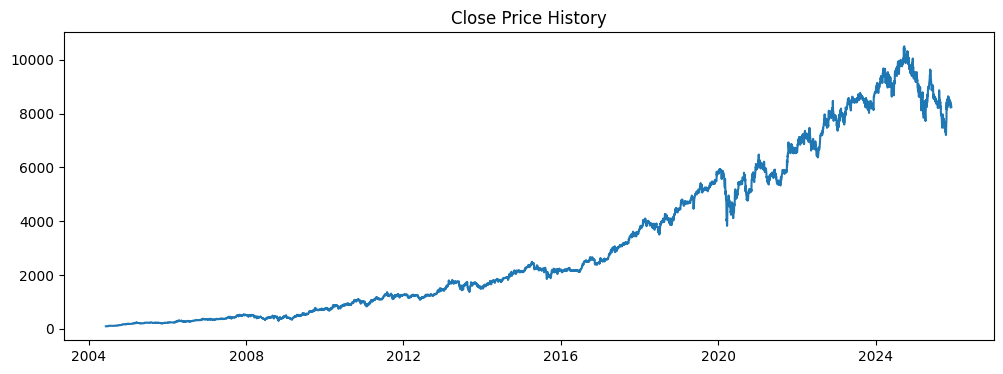

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(df['Close'])
plt.title('Close Price History')
plt.show()

In [ ]:
def computer_rsi(series, window=14):
  delta = series.diff()
  gain = np.where(delta > 0, delta, 0.0)
  loss = np.where(delta < 0, -delta, 0.0)
  gain = pd.Series(gain, index=series.index)
  loss = pd.Series(loss, index=series.index)
  avg_gain = gain.rolling(window=window).mean()
  avg_loss = loss.rolling(window=window).mean()
  rs = avg_gain / (avg_loss + 1e-10)
  rsi = 100 - (100 / (1 + rs))
  return rsi

def compute_macd(series, span_fast=12, span_slow=26, span_signal=9):
  ema_fast = series.ewm(span=span_fast, adjust=False).mean()
  ema_slow = series.ewm(span=span_slow, adjust=False).mean()
  macd = ema_fast - ema_slow
  signal = macd.ewm(span=span_signal, adjust=False).mean()
  hist = macd - signal
  return macd, signal, hist

def compute_bollinger_bands(series, window=20, n_std=2):
  sma = series.rolling(window=window).mean()
  std = series.rolling(window=window).std()
  upper = sma + n_std * std
  lower = sma - n_std * std
  return sma, upper, lower

In [ ]:
fe = df.copy()

# Indikator teknikal
fe['RSI_14'] = computer_rsi(fe['Close'], window=14)
fe['MACD'], fe['MACD_signal'], fe['MACD_hist'] = compute_macd(fe['Close'])
fe['BB_mid'], fe['BB_upper'], fe['BB_lower'] = compute_bollinger_bands(fe['Close'], window=20, n_std=2)

fe[['Close', 'RSI_14', 'MACD', 'MACD_signal', 'BB_mid', 'BB_upper', 'BB_lower']].tail()

,Close,RSI_14,MACD,MACD_signal,BB_mid,BB_upper,BB_lower
Date,,,,,,,
2025-11-28,8220.656250,37.999954,52.404212,99.367481,8433.002881,8670.660262,8195.345500
2025-12-01,8344.835938,50.000000,47.749859,89.043957,8420.584961,8648.764442,8192.405480
2025-12-02,8320.000000,44.444454,41.577915,79.550748,8406.925244,8624.037628,8189.812860
2025-12-03,8300.000000,49.013254,34.673082,70.575215,8389.781982,8581.061326,8198.502639
2025-12-04,8250.000000,44.097622,24.879573,61.436087,8377.589453,8571.999526,8183.179380


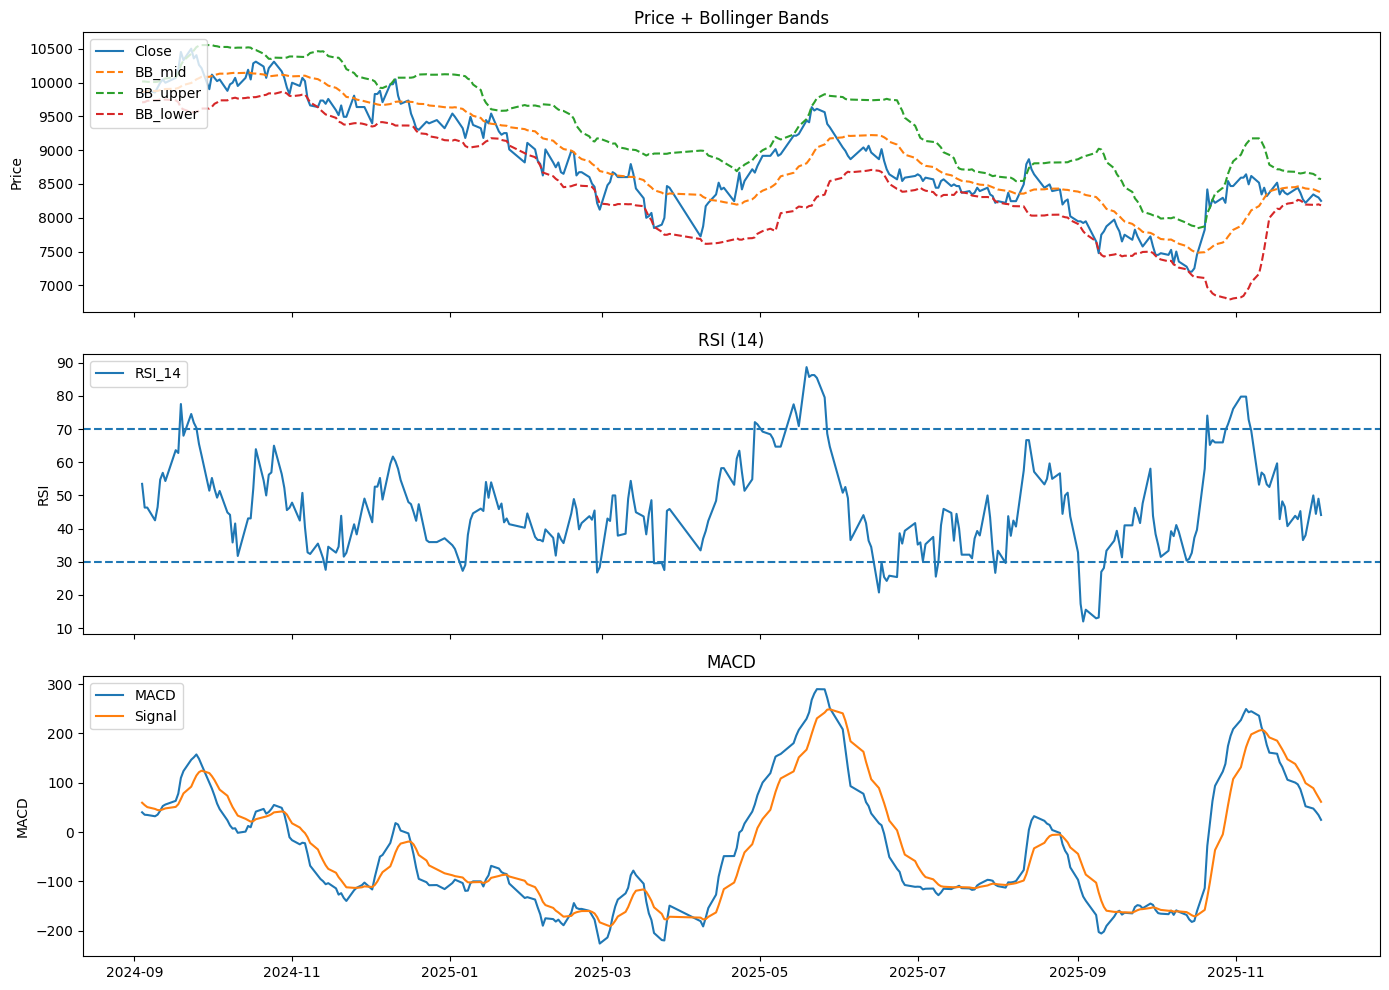

In [ ]:
# visualisasi fitur teknikal

fe_plot = fe.copy().dropna().tail(300)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
ax_price, ax_rsi, ax_macd = axes

# Harga + Bollinger bands
ax_price.plot(fe_plot.index, fe_plot['Close'], label='Close')
ax_price.plot(fe_plot.index, fe_plot['BB_mid'], label='BB_mid', linestyle='--')
ax_price.plot(fe_plot.index, fe_plot['BB_upper'], label='BB_upper', linestyle='--')
ax_price.plot(fe_plot.index, fe_plot['BB_lower'], label='BB_lower', linestyle='--')
ax_price.set_ylabel('Price')
ax_price.set_title('Price + Bollinger Bands')
ax_price.legend(loc='upper left')

# RSI
ax_rsi.plot(fe_plot.index, fe_plot['RSI_14'], label='RSI_14')
ax_rsi.axhline(70, linestyle='--') # overbought
ax_rsi.axhline(30, linestyle='--') # oversold
ax_rsi.set_ylabel('RSI')
ax_rsi.set_title('RSI (14)')
ax_rsi.legend(loc='upper left')

# MACD
ax_macd.plot(fe_plot.index, fe_plot['MACD'], label='MACD')
ax_macd.plot(fe_plot.index, fe_plot['MACD_signal'], label='Signal')
ax_macd.set_ylabel('MACD')
ax_macd.set_title('MACD')
ax_macd.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
# return harian
fe['return_1'] = fe['Close'].pct_change()

# Lag features
fe['lag_1'] = fe['Close'].shift(1)
fe['lag_3'] = fe['Close'].shift(3)
fe['lag_5'] = fe['Close'].shift(5)

# Rolling stats
fe['roll_mean_3'] = fe['Close'].rolling(window=3).mean()
fe['roll_mean_7'] = fe['Close'].rolling(window=7).mean()
fe['roll_std_7'] = fe['Close'].rolling(window=7).std()

# Fitur waktu
fe['dow'] = fe.index.dayofweek

# Target: Close Besok
fe['target'] = fe['Close'].shift(-1)

# Drop missing values
fe = fe.dropna().copy()

feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'return_1',
                'lag_1', 'lag_3', 'lag_5', 'roll_mean_3', 'roll_mean_7',
                'roll_std_7', 'RSI_14', 'MACD', 'MACD_signal', 'MACD_hist',
                'BB_mid', 'BB_upper', 'BB_lower', 'dow']

X = fe[feature_cols]
y = fe['target']

print(f'Jumlah fitur :', len(feature_cols))
print(f'Shape X, y :', X.shape, y.shape)
fe.head()

Jumlah fitur : 20
Shape X, y : (5286, 20) (5286,)


,Open,Close,High,Low,Volume,RSI_14,MACD,MACD_signal,MACD_hist,BB_mid,...,BB_lower,return_1,lag_1,lag_3,lag_5,roll_mean_3,roll_mean_7,roll_std_7,dow,target
Date,,,,,,,,,,,,,,,,,,,,,
2004-07-05,114.132126,114.132126,114.132126,114.132126,0,84.397113,3.048648,1.464583,1.584065,102.550906,...,92.548813,0.000000,114.132126,104.621155,101.831253,113.603752,107.474447,5.834670,0,118.887665
2004-07-06,115.717327,118.887665,118.887665,114.132158,826610000,93.432960,3.832087,1.938084,1.894003,103.543222,...,91.316609,0.041667,114.132126,112.547005,103.226212,115.717306,109.911077,6.596919,1,118.887665
2004-07-07,117.302496,118.887665,120.472834,115.717327,382570000,100.000000,4.402221,2.430911,1.971310,104.465791,...,90.557415,0.000000,118.887665,114.132126,104.621155,117.302485,112.347707,6.256349,2,118.887665
2004-07-08,118.887665,118.887665,120.472834,117.302496,284740000,100.000000,4.798740,2.904477,1.894263,105.388361,...,90.215084,0.000000,118.887665,114.132126,112.547005,118.887665,114.585058,5.153973,3,120.472847
2004-07-09,117.302509,120.472847,120.472847,117.302509,381140000,100.000000,5.181170,3.359816,1.821354,106.390190,...,89.996803,0.013333,118.887665,118.887665,114.132126,119.416059,116.849585,3.132377,4,120.472847


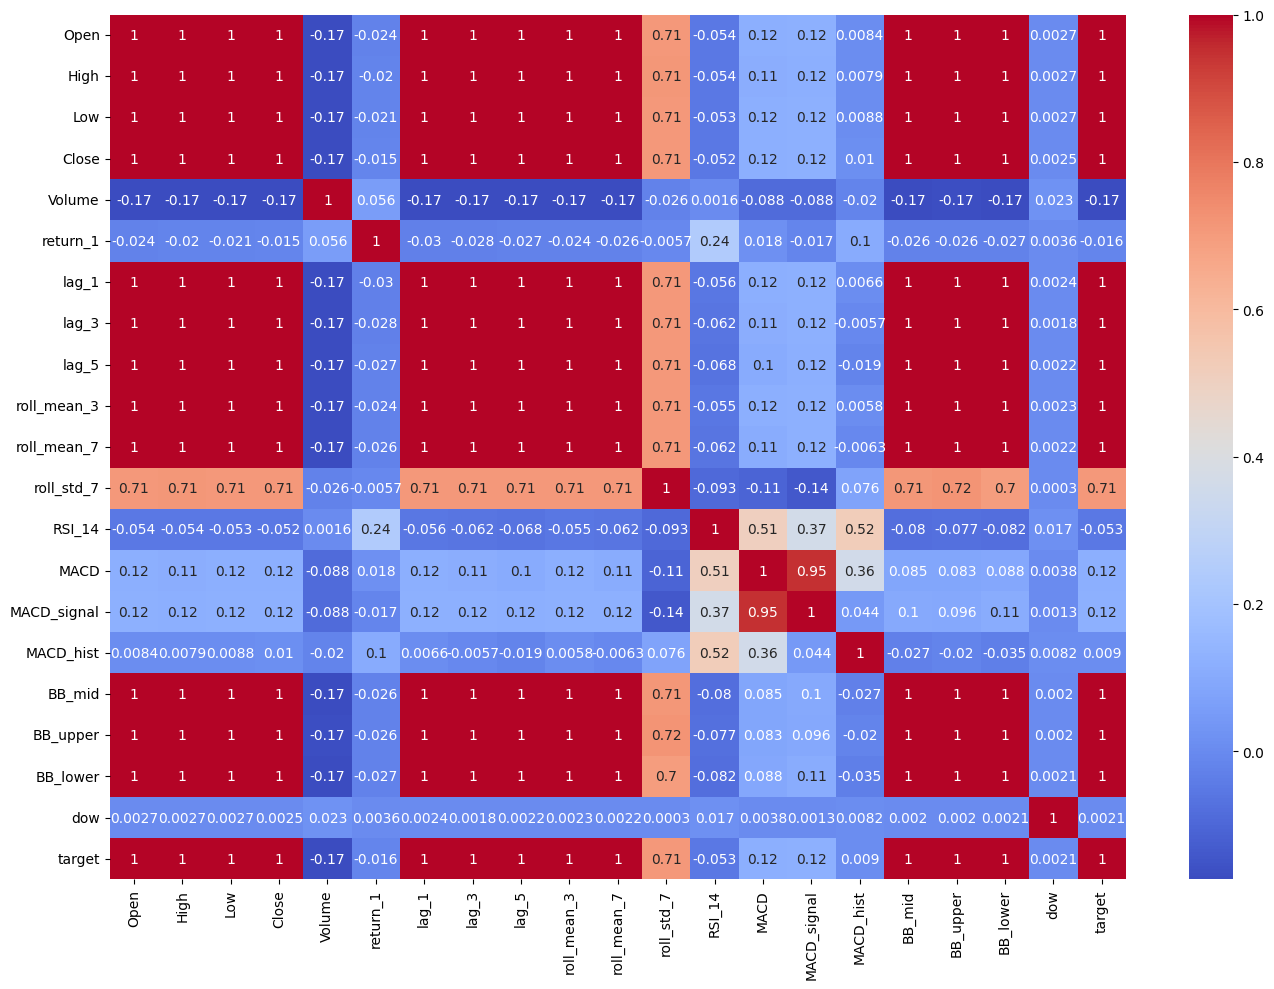

In [ ]:
import seaborn as sns

corr = fe[feature_cols+['target']].corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.tight_layout()
plt.show()

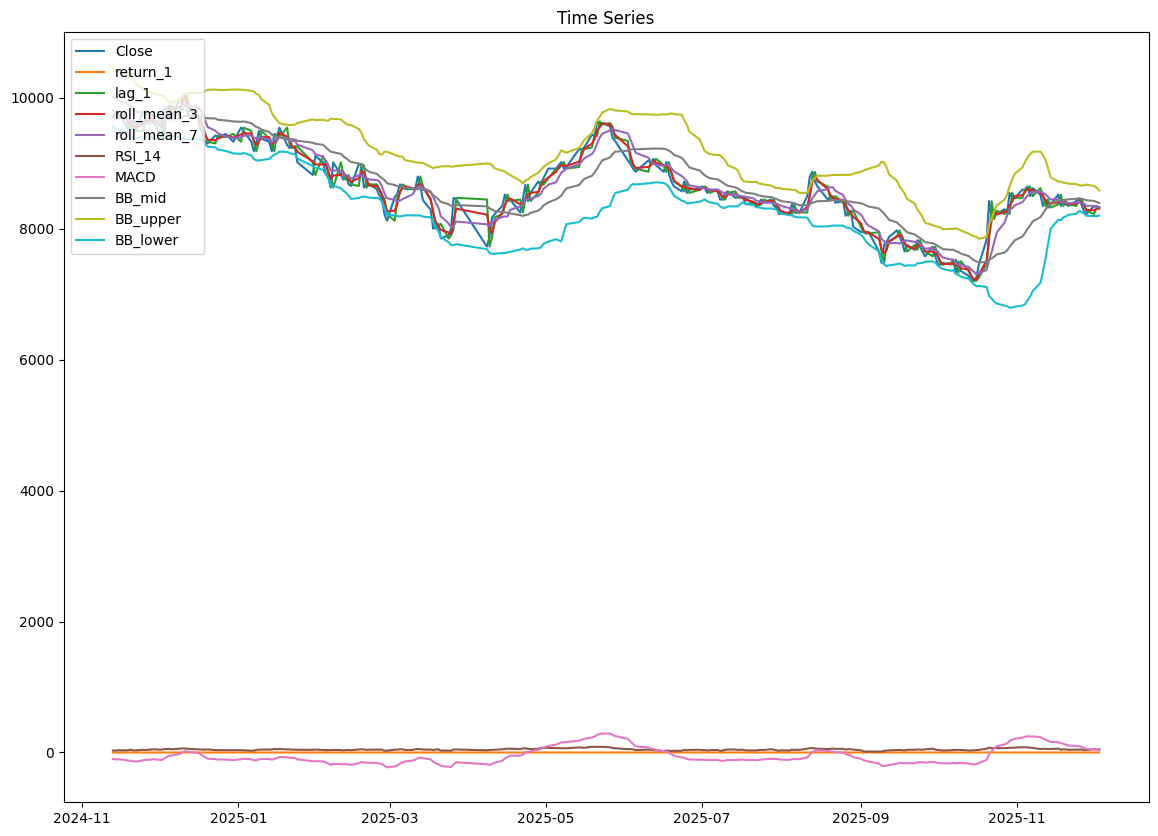

In [ ]:
fe_plot = fe.tail(250)

cols_ts = [
    'Close', 'return_1', 'lag_1', 'roll_mean_3', 'roll_mean_7', 'RSI_14', 'MACD',
    'BB_mid', 'BB_upper', 'BB_lower'
]

plt.figure(figsize=(14,10))
for col in cols_ts:
    plt.plot(fe_plot.index, fe_plot[col], label=col)

plt.title('Time Series')
plt.legend(loc='upper left')
plt.show()

In [ ]:
last_date = fe.index.max()
test_day = 30
split_date_test = last_date - pd.Timedelta(days=test_day)

X_train_full = X[fe.index <= split_date_test].copy()
y_train_full = y[fe.index <= split_date_test].copy()
X_test = X[fe.index > split_date_test].copy()
y_test = y[fe.index > split_date_test].copy()

print(f'Train full shape :', X_train_full.shape)
print(f'Test shape :', X_test.shape)

Train full shape : (5264, 20)
Test shape : (22, 20)


In [ ]:
n_train_full = len(X_train_full)
n_val = int(0.2 * n_train_full)

X_train = X_train_full.iloc[:-n_val]
y_train = y_train_full.iloc[:-n_val]
X_val = X_train_full.iloc[-n_val:]
y_val = y_train_full.iloc[-n_val:]

print(f'Train shape :', X_train.shape)
print(f'Val shape :', X_val.shape)

Train shape : (4212, 20)
Val shape : (1052, 20)


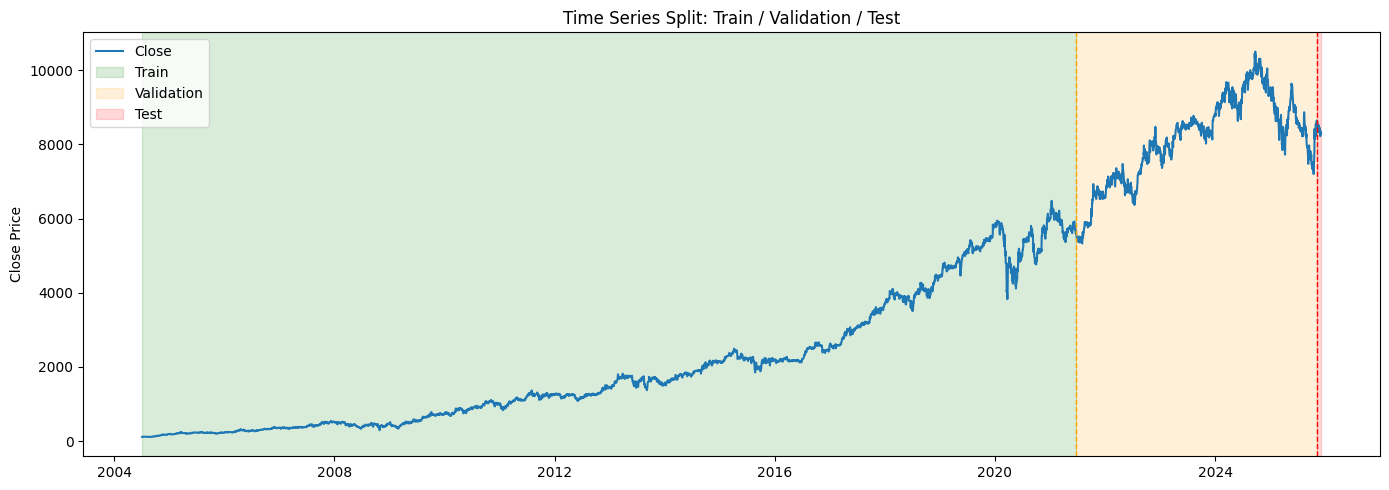

In [ ]:
fe_plot = fe.copy()

fig, ax = plt.subplots(figsize=(14, 5))

# plot harga
ax.plot(fe_plot.index, fe_plot['Close'], label='Close', linewidth=1.5)

# ambil batas - batas indeks dari setiap split
train_start = fe_plot.index.min()
train_end = X_train.index.max()

val_start = X_val.index.min()
val_end = X_val.index.max()

test_start = X_test.index.min()
test_end = fe_plot.index.max()

# highlight tiap region (train / val / test)
ax.axvspan(train_start, train_end, alpha=0.15, label='Train', color='green')
ax.axvspan(val_start, val_end, alpha=0.15, label='Validation', color='orange')
ax.axvspan(test_start, test_end, alpha=0.15, label='Test', color='red')

# tambah garis vertikal untuk penanda jelas
ax.axvline(val_start, linestyle='--', linewidth=1, color='orange')
ax.axvline(test_start, linestyle='--', linewidth=1, color='red')

ax.set_title('Time Series Split: Train / Validation / Test')
ax.set_ylabel('Close Price')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
def regression_metrics(y_true, y_pred, name='model'):
  mae = mean_absolute_error(y_true, y_pred)
  mse = mean_squared_error(y_true, y_pred)
  rmse = np.sqrt(mse)
  mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
  print(f'==={name} Metrics===')
  print(f'MAE: {mae:.4f}')
  print(f'MSE: {mse:.4f}')
  print(f'RMSE: {rmse:.4f}')
  print(f'MAPE: {mape:.2f}%')
  return mae, mse, rmse, mape

In [ ]:
close_series = df['Close'].copy()
close_series = close_series.asfreq('B').ffill() # pastikan frekuensi bisnis & isi gap hari libur

# tentukan split ARIMA sama dengan split_date_test
arima_train = close_series[close_series.index <= split_date_test]
arima_test = close_series[close_series.index > split_date_test]

print(f'ARIMA train size :', arima_train.shape)
print(f'ARIMA test size :', arima_test.shape)

model_arima = auto_arima(
    arima_train,
    seasonal=False,
    trace=False,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

n_test_arima = len(arima_test)
y_pred_arima = model_arima.predict(n_periods=n_test_arima)

mae_arima, mse_arima, rmse_arima, mape_arima = regression_metrics(arima_test, y_pred_arima, name='Auto ARIMA')

ARIMA train size : (5585,)
ARIMA test size : (23,)
===Auto ARIMA Metrics===
MAE: 146.1322
MSE: 27993.2070
RMSE: 167.3117
MAPE: 1.75%


In [ ]:
print(model_arima.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 5585
Model:               SARIMAX(1, 1, 2)   Log Likelihood              -30979.682
Date:                Thu, 04 Dec 2025   AIC                          61969.363
Time:                        03:32:15   BIC                          62002.502
Sample:                    06-08-2004   HQIC                         61980.913
                         - 11-03-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.1859      0.114      1.630      0.103      -0.038       0.409
ar.L1          0.8763      0.046     18.924      0.000       0.785       0.967
ma.L1         -0.9936      0.048    -20.737      0.0

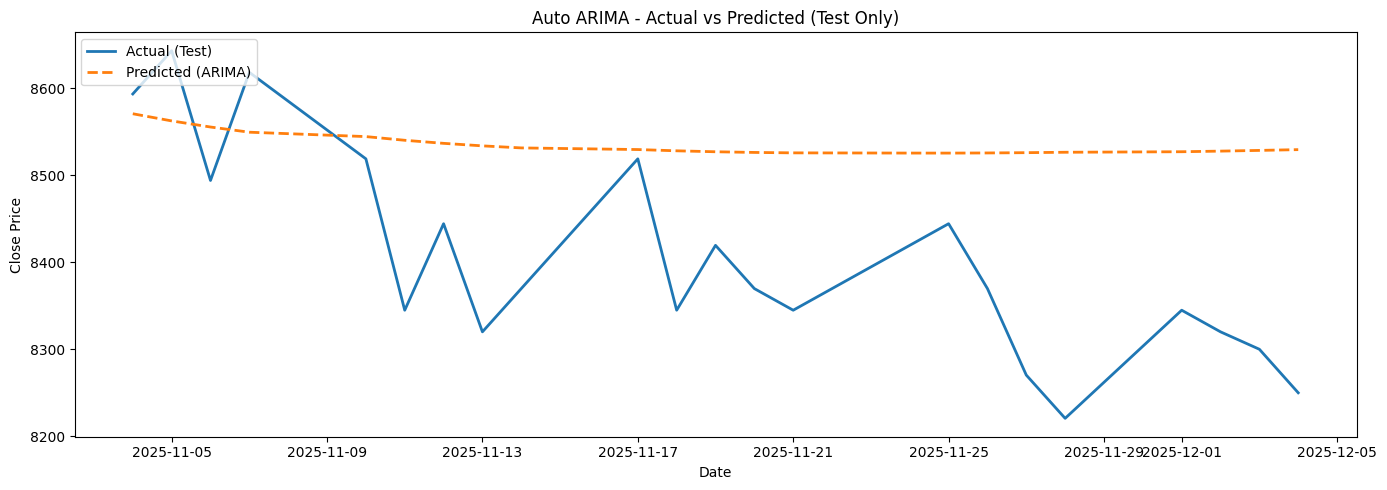

In [ ]:
y_pred_arima_series = pd.Series(y_pred_arima, index=arima_test.index)

plt.figure(figsize=(14, 5))

plt.plot(arima_test.index, arima_test, label='Actual (Test)', linewidth=2)
plt.plot(y_pred_arima_series.index, y_pred_arima_series, label='Predicted (ARIMA)', linestyle='--', linewidth=2)

plt.title('Auto ARIMA - Actual vs Predicted (Test Only)')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
arima_compare = pd.DataFrame({
    'Actual': arima_test,
    'Predicted' : y_pred_arima
})

print(arima_compare.head())

                 Actual    Predicted
2025-11-04  8593.194336  8570.464870
2025-11-05  8642.865234  8562.247348
2025-11-06  8493.850586  8555.232618
2025-11-07  8618.029297  8549.271838
2025-11-10  8518.686523  8544.234587


In [ ]:
prophet_df = close_series.reset_index().rename(columns={'Date': 'ds', 'Close': 'y'})

train_prophet = prophet_df[prophet_df['ds'] <= split_date_test]
test_prophet = prophet_df[prophet_df['ds'] > split_date_test]

m_prophet = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=True)
m_prophet.fit(train_prophet)

future_test = test_prophet[['ds']]
forecast_test = m_prophet.predict(future_test)
y_pred_prophet = forecast_test['yhat'].values

mae_prophet, mse_prophet, rmse_prophet, mape_prophet = regression_metrics(test_prophet['y'].values, y_pred_prophet, name='Prophet')

===Prophet Metrics===
MAE: 1458.7755
MSE: 2145222.3450
RMSE: 1464.6578
MAPE: 17.38%


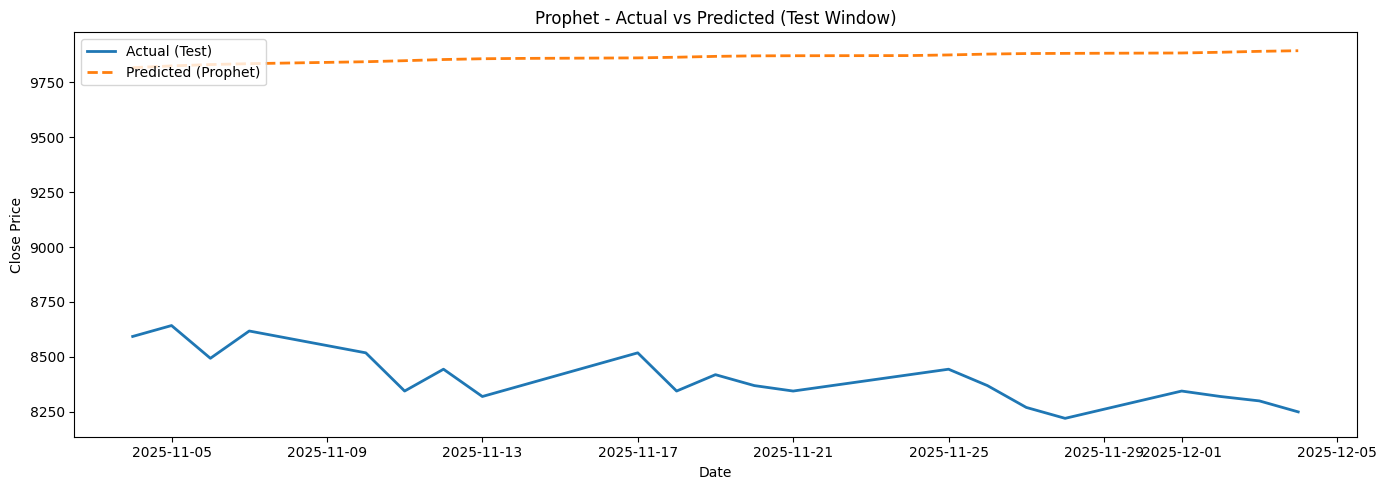

In [ ]:
y_pred_prophet_series = pd.Series(
    y_pred_prophet,
    index=test_prophet['ds']
)

plt.figure(figsize=(14, 5))

# Actual (test)
plt.plot(
    test_prophet['ds'],
    test_prophet['y'],
    label='Actual (Test)',
    linewidth=2
)

# Predicted (Prophet)
plt.plot(
    y_pred_prophet_series.index,
    y_pred_prophet_series,
    label='Predicted (Prophet)',
    linestyle='--',
    linewidth=2
)

plt.title('Prophet - Actual vs Predicted (Test Window)')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
xgb = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='rmse',
    tree_method='hist'
)

xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=0
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb = xgb.predict(X_test)

mae_xgb, mse_xgb, rmse_xgb, mape_xgb = regression_metrics(y_test, y_pred_xgb, name='XGBoost')

===XGBoost Metrics===
MAE: 2251.5401
MSE: 5078895.9445
RMSE: 2253.6406
MAPE: 26.81%


In [ ]:
# tuning xgboost with grid search
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, None],
    'learning_rate': [0.01, 0.05, 0.1],
}

grid_search = GridSearchCV(
    estimator=XGBRegressor(),
    param_grid=params,
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=1,
)

In [ ]:
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 36 candidates, totalling 108 fits


GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None...
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 4, 5, None],
                         'n_estimators': [100, 200, 300]},
             scoring='neg_mean_squared_error', verbose=1)

In [ ]:
print(f'Best parameters: {grid_search.best_params_}')
print(f'Best score: {grid_search.best_score_}')

Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
Best score: -1621909.9172707803


In [ ]:
best_xgb = grid_search.best_estimator_
best_xgb.fit(X_train, y_train)
ypred_tune_xgb = best_xgb.predict(X_test)

mae_tune_xgb, mse_tune_xgb, rmse_tune_xgb, mape_tune_xgb = regression_metrics(y_test, ypred_tune_xgb, name='Tuned XGBoost')

===Tuned XGBoost Metrics===
MAE: 2210.6325
MSE: 4894419.7281
RMSE: 2212.3335
MAPE: 26.32%


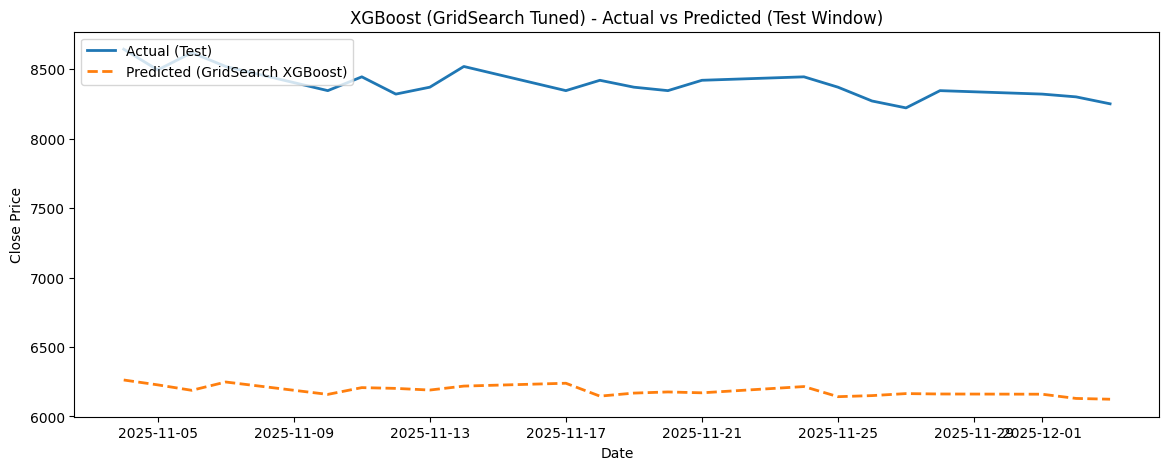

In [ ]:
y_pred_xgb_grid_series = pd.Series(
    ypred_tune_xgb,
    index=y_test.index
)

plt.figure(figsize=(14, 5))

# Actual (test)
plt.plot(
    y_test.index,
    y_test,
    label='Actual (Test)',
    linewidth=2
)

plt.plot(
    y_pred_xgb_grid_series.index,
    y_pred_xgb_grid_series.values,
    label='Predicted (GridSearch XGBoost)',
    linestyle='--',
    linewidth=2
)

plt.title('XGBoost (GridSearch Tuned) - Actual vs Predicted (Test Window)')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend(loc='upper left')

In [ ]:
y_pred_xgb_grid_series

,0
Date,
2025-11-04,6262.596191
2025-11-05,6227.532715
2025-11-06,6188.303711
2025-11-07,6248.104980
2025-11-10,6158.961426
2025-11-11,6207.708496
2025-11-12,6202.210449
2025-11-13,6190.258301
2025-11-14,6218.768066


In [ ]:
# Scalling Data for XGBoost
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Tuning xgboost

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=3)

params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, None],
    'learning_rate': [0.01, 0.05, 0.1],
}

grid_search = GridSearchCV(
    estimator=XGBRegressor(),
    param_grid=params,
    scoring='neg_mean_squared_error',
    cv=tscv,
    verbose=1,
)

grid_search.fit(X_train_scaled, y_train,
                eval_set=[(X_val_scaled, y_val)],
                verbose=0
                )

Fitting 3 folds for each of 36 candidates, totalling 108 fits


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None),
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None...
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 4, 5, None],
                         'n_estimators': [100, 200, 300]},
             scoring='neg_mean_squared_error', verbose=1)

In [ ]:
best_xgb = grid_search.best_estimator_
best_xgb.fit(X_train_scaled, y_train)
ypred_tune_xgb_scaled = best_xgb.predict(X_test_scaled)

mae_tune_xgb, mse_tune_xgb, rmse_tune_xgb, mape_tune_xgb = regression_metrics(y_test, ypred_tune_xgb_scaled, name='Tuned Scaled XGBoost')

===Tuned Scaled XGBoost Metrics===
MAE: 2201.9756
MSE: 4856180.6568
RMSE: 2203.6744
MAPE: 26.22%


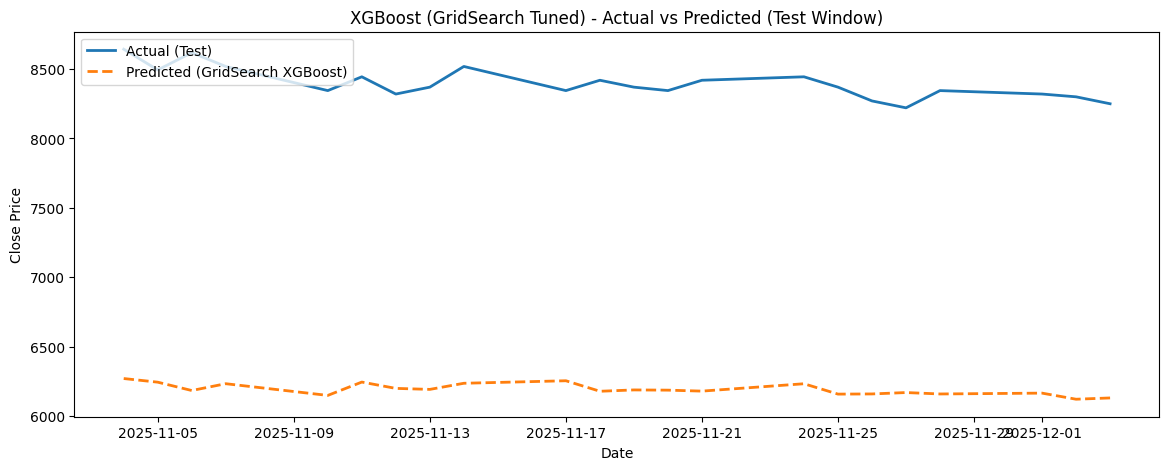

In [ ]:
y_pred_xgb_grid_series = pd.Series(
    ypred_tune_xgb_scaled,
    index=y_test.index
)

plt.figure(figsize=(14, 5))

# Actual (test)
plt.plot(
    y_test.index,
    y_test,
    label='Actual (Test)',
    linewidth=2
)

plt.plot(
    y_pred_xgb_grid_series.index,
    y_pred_xgb_grid_series.values,
    label='Predicted (GridSearch XGBoost)',
    linestyle='--',
    linewidth=2
)

plt.title('XGBoost (GridSearch Tuned) - Actual vs Predicted (Test Window)')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend(loc='upper left')

In [ ]:
# minmax scaller for deeplearning

from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()
X_train_scaled = minmax.fit_transform(X_train)
X_val_scaled = minmax.transform(X_val)
X_test_scaled = minmax.transform(X_test)

In [ ]:
# dense model

input_dim = X_train_scaled.shape[1]
model_dense = Sequential()
model_dense.add(Dense(128, input_dim=input_dim, activation='relu'))
model_dense.add(Dropout(0.2))

model_dense.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
input_dim

20

In [ ]:
model_dense.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_dense.compile(
    loss='mse',
    optimizer='adam',
    metrics=['mae']
)

es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=20)

In [ ]:
history_dense = model_dense.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs = 100,
    batch_size = 32,
    callbacks=[es],
    verbose=0
)

In [ ]:
test_loss, test_mae = model_dense.evaluate(X_test_scaled, y_test)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test MAE: {test_mae:.4f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - loss: 108814.1484 - mae: 319.9135
Test Loss: 108814.1484
Test MAE: 319.9135


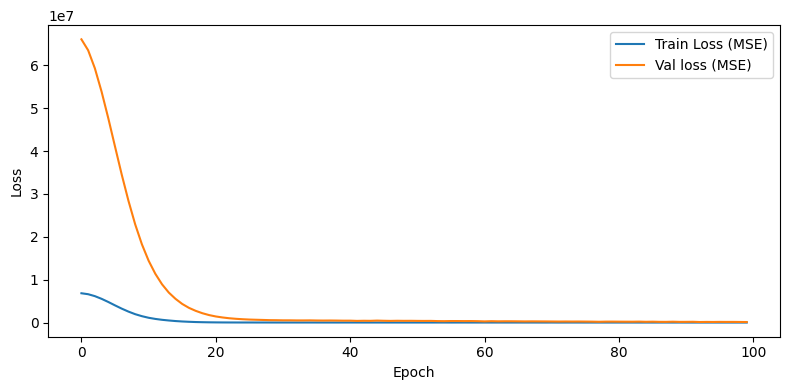

In [ ]:
plt.figure(figsize=(8, 4))

plt.plot(history_dense.history['loss'], label='Train Loss (MSE)')
plt.plot(history_dense.history['val_loss'], label='Val loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend('Dense NN - Training vs Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
y_pred_dense = model_dense.predict(X_test_scaled).ravel()
mae_dense, mse_dense, rmse_dense, mape_dense = regression_metrics(y_test, y_pred_dense, name='Dense NN')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
===Dense NN Metrics===
MAE: 319.9135
MSE: 108814.1500
RMSE: 329.8699
MAPE: 3.81%


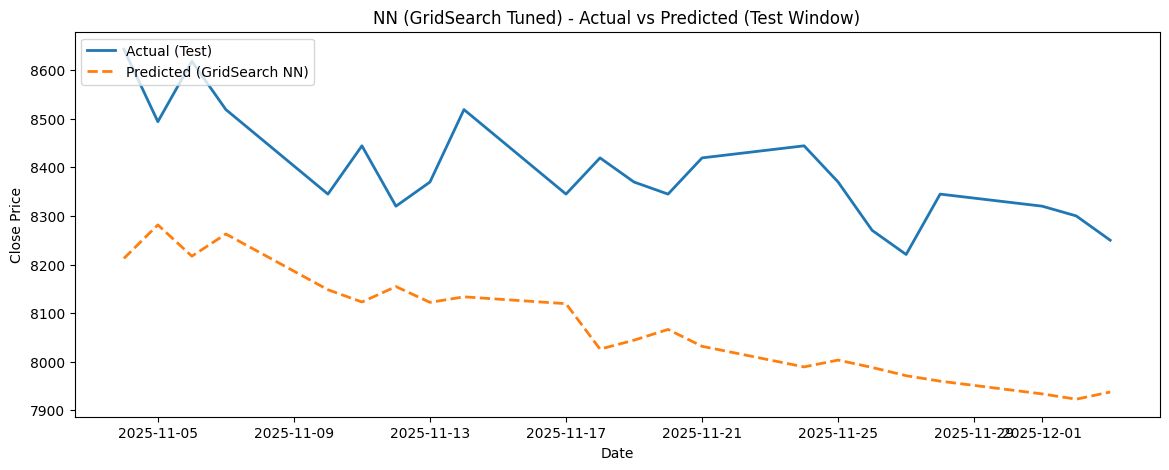

In [ ]:
y_pred_xgb_grid_series = pd.Series(
    y_pred_dense,
    index=y_test.index
)

plt.figure(figsize=(14, 5))

# Actual (test)
plt.plot(
    y_test.index,
    y_test,
    label='Actual (Test)',
    linewidth=2
)

plt.plot(
    y_pred_xgb_grid_series.index,
    y_pred_xgb_grid_series.values,
    label='Predicted (GridSearch NN)',
    linestyle='--',
    linewidth=2
)

plt.title('NN (GridSearch Tuned) - Actual vs Predicted (Test Window)')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend(loc='upper left')

In [ ]:
y_pred_xgb_grid_series

,0
Date,
2025-11-04,8212.482422
2025-11-05,8281.546875
2025-11-06,8217.195312
2025-11-07,8262.786133
2025-11-10,8148.131836
2025-11-11,8122.899902
2025-11-12,8154.656738
2025-11-13,8122.130371
2025-11-14,8133.524902


In [ ]:
def build_dense_model(hp):
    n_hidden = hp.Int('n_hidden', min_value=2, max_value=512, step=2)
    dropout_rate = hp.Float('dropout', 0.0, 0.4, step=0.1)
    lr = hp.Choice('learning_rate', [1e-2, 1e-3, 5e-4])

    model = Sequential()
    model.add(Dense(n_hidden, activation='relu', input_shape=(X_train_scaled.shape[1],)))
    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))
    model.add(Dense(1))

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr), loss='mse')
    return model

tuner_dense = kt.RandomSearch(
    build_dense_model,
    objective='val_loss',
    max_trials=10,
    directory='tuner_dir',
    project_name='dense_nn_tuning',
    overwrite=True,
)

es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

tuner_dense.search(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[es],
    verbose=1,
)

best_hp_dense = tuner_dense.get_best_hyperparameters(1)[0]
best_hp_dense.values

Trial 10 Complete [00h 00m 26s]
val_loss: 29515.501953125

Best val_loss So Far: 15915.6083984375
Total elapsed time: 00h 05m 53s


{'n_hidden': 352, 'dropout': 0.30000000000000004, 'learning_rate': 0.01}

In [ ]:
best_hp_dense = tuner_dense.get_best_hyperparameters(1)[0]
best_hp_dense.values

{'n_hidden': 352, 'dropout': 0.30000000000000004, 'learning_rate': 0.01}

In [ ]:
model_dense = tuner_dense.hypermodel.build(best_hp_dense)

model_dense.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 352)            │         7,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 352)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           353 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,745 (30.25 KB)

 Trainable params: 7,745 (30.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_dense.compile(
    loss='mse',
    optimizer='adam',
    metrics=['mae']
)

In [ ]:
best_lr = best_hp_dense.get('learning_rate')

model_dense.compile(
    loss='mse',
    optimizer=tf.keras.optimizers.Adam(learning_rate=best_lr),
    metrics=['mae']
)

In [ ]:
es = EarlyStopping(
    monitor='val_loss',
    mode='min',
    verbose=1,
    patience=20,
    restore_best_weights=True
)

history_dense = model_dense.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs = 100,
    batch_size = 32,
    callbacks=[es],
    verbose=0
)

Restoring model weights from the end of the best epoch: 95.


In [ ]:
test_loss, test_mae = model_dense.evaluate(X_test_scaled, y_test, verbose=0)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test MAE: {test_mae:.4f}')

Test Loss: 7695.0811
Test MAE: 69.0478


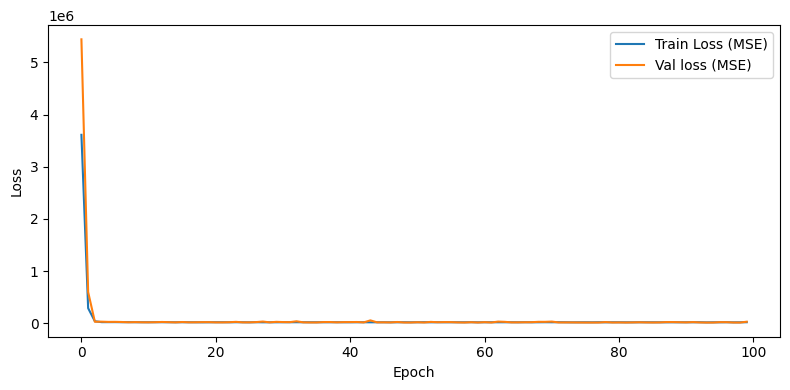

In [ ]:
plt.figure(figsize=(8, 4))

plt.plot(history_dense.history['loss'], label='Train Loss (MSE)')
plt.plot(history_dense.history['val_loss'], label='Val loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend('Dense NN - Training vs Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
y_pred_dense = model_dense.predict(X_test_scaled).ravel()
mae_dense, mse_dense, rmse_dense, mape_dense = regression_metrics(y_test, y_pred_dense, name='Dense NN')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step
===Dense NN Metrics===
MAE: 69.0478
MSE: 7695.0805
RMSE: 87.7216
MAPE: 0.82%


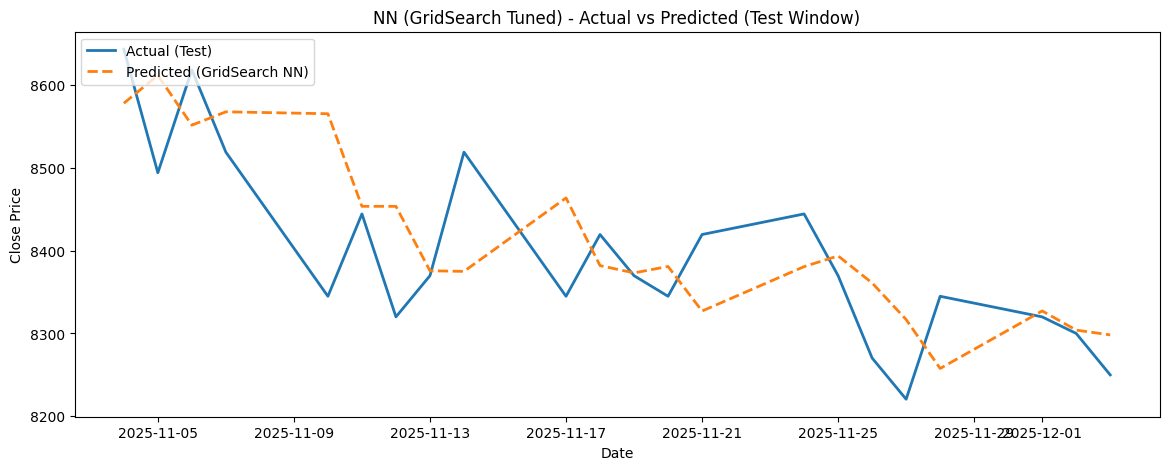

In [ ]:
y_pred_xgb_grid_series = pd.Series(
    y_pred_dense,
    index=y_test.index
)

plt.figure(figsize=(14, 5))

# Actual (test)
plt.plot(
    y_test.index,
    y_test,
    label='Actual (Test)',
    linewidth=2
)

plt.plot(
    y_pred_xgb_grid_series.index,
    y_pred_xgb_grid_series.values,
    label='Predicted (GridSearch NN)',
    linestyle='--',
    linewidth=2
)

plt.title('NN (GridSearch Tuned) - Actual vs Predicted (Test Window)')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend(loc='upper left')

In [ ]:
input_dim = X_train_scaled.shape[1]

model_deep = Sequential()

# Hidden layer 1
model_deep.add(Dense(128, activation='relu', input_shape=(input_dim,)))
model_deep.add(Dropout(0.3))

# Hidden layer 2
model_deep.add(Dense(64, activation='relu'))
model_deep.add(Dropout(0.2))

# Hidden layer 3 (opsional, bisa dibuang kalau mau lebih ringan)
model_deep.add(Dense(32, activation='relu'))

# Output layer (regresi -> linear)
model_deep.add(Dense(1, activation='linear'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# compile model
model_deep.compile(
    loss='mse',
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=['mae']
)

model_deep.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,057 (51.00 KB)

 Trainable params: 13,057 (51.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Early Stopping

es = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

# Train
history_deep = model_deep.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[es],
    verbose=0
)

# Evaluate
test_loss, test_mae = model_deep.evaluate(X_test_scaled, y_test, verbose=0)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test MAE: {test_mae:.4f}')

Epoch 100: early stopping
Restoring model weights from the end of the best epoch: 80.
Test Loss: 7242.0532
Test MAE: 68.4341


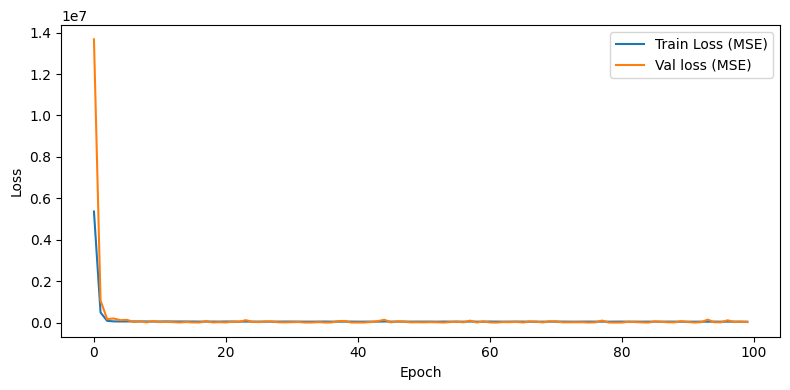

In [ ]:
plt.figure(figsize=(8, 4))

plt.plot(history_deep.history['loss'], label='Train Loss (MSE)')
plt.plot(history_deep.history['val_loss'], label='Val loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend('Dense NN - Training vs Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()